In [6]:
!cd ~/c/iu9-sql-compiler/ && ./build-release/bin/benchmarks --benchmark_filter='OperatorCost*' --benchmark_out=/tmp/operator-cost.json --benchmark_out_format=json

2026-05-30T19:44:06+03:00
Running ./build-release/bin/benchmarks
Run on (8 X 4200 MHz CPU s)
CPU Caches:
  L1 Data 48 KiB (x4)
  L1 Instruction 32 KiB (x4)
  L2 Unified 1280 KiB (x4)
  L3 Unified 8192 KiB (x1)
Load Average: 0.78, 1.77, 2.40
***WARNING*** CPU scaling is enabled, the benchmark real time measurements may be noisy and will incur extra overhead.
-------------------------------------------------------------------------------------------------------------
Benchmark                                                   Time             CPU   Iterations UserCounters...
-------------------------------------------------------------------------------------------------------------
OperatorCost/SeqScan/1024/real_time                     49602 ns        49352 ns        12617 model_cost=1.024k output_rows=1.024k rows=1.024k
OperatorCost/SeqScan/4096/real_time                    217833 ns       215541 ns         3460 model_cost=4.096k output_rows=4.096k rows=4.096k
OperatorCost/SeqScan/163

In [7]:
!ls -l /tmp | grep operator-cost

-rw-r--r--  1 st     users   22146 May 30 19:44 operator-cost.json
-rw-r--r--  1 st     users    2010 May 30 19:02 operator-cost-smoke.json


In [2]:
import json

results = None
with open('/tmp/operator-cost.json') as f:
    results = json.load(f)

results

{'context': {'date': '2026-05-30T19:44:06+03:00',
  'host_name': 'nixos',
  'executable': './build-release/bin/benchmarks',
  'num_cpus': 8,
  'mhz_per_cpu': 4200,
  'cpu_scaling_enabled': True,
  'caches': [{'type': 'Data', 'level': 1, 'size': 49152, 'num_sharing': 2},
   {'type': 'Instruction', 'level': 1, 'size': 32768, 'num_sharing': 2},
   {'type': 'Unified', 'level': 2, 'size': 1310720, 'num_sharing': 2},
   {'type': 'Unified', 'level': 3, 'size': 8388608, 'num_sharing': 8}],
  'load_avg': [0.782715, 1.77148, 2.39893],
  'library_version': 'v1.9.0',
  'library_build_type': 'release',
  'json_schema_version': 1},
 'benchmarks': [{'name': 'OperatorCost/SeqScan/1024/real_time',
   'family_index': 0,
   'per_family_instance_index': 0,
   'run_name': 'OperatorCost/SeqScan/1024/real_time',
   'run_type': 'iteration',
   'repetitions': 1,
   'repetition_index': 0,
   'threads': 1,
   'iterations': 12617,
   'real_time': 49602.278037666736,
   'cpu_time': 49352.30649124199,
   'time_unit

In [5]:
import pandas as pd

df = pd.DataFrame(results['benchmarks'])
df = df[df['run_type'] == 'iteration'].copy()

parts = df['name'].str.split('/')
df['operator'] = parts.str[1]
df['left_rows'] = parts.str[2].astype(int)
df['right_rows'] = parts.apply(lambda p: int(p[3]) if len(p) == 5 else None)

df['real_time_ms'] = df['real_time'] / 1e6

df[['operator', 'left_rows', 'right_rows', 'real_time_ms', 'model_cost']].sort_values(['operator', 'left_rows'])

,operator,left_rows,right_rows,real_time_ms,model_cost
20,Aggregation,1024,NaN,0.360181,1024.0
21,Aggregation,4096,NaN,1.595273,4096.0
22,Aggregation,16384,NaN,7.530658,16384.0
23,Aggregation,65536,NaN,63.945720,65536.0
24,Aggregation,262144,NaN,375.139164,262144.0
5,Filter,1024,NaN,0.093398,1024.0
6,Filter,4096,NaN,0.320979,4096.0
7,Filter,16384,NaN,1.286237,16384.0
8,Filter,65536,NaN,5.559294,65536.0
9,Filter,262144,NaN,24.117997,262144.0


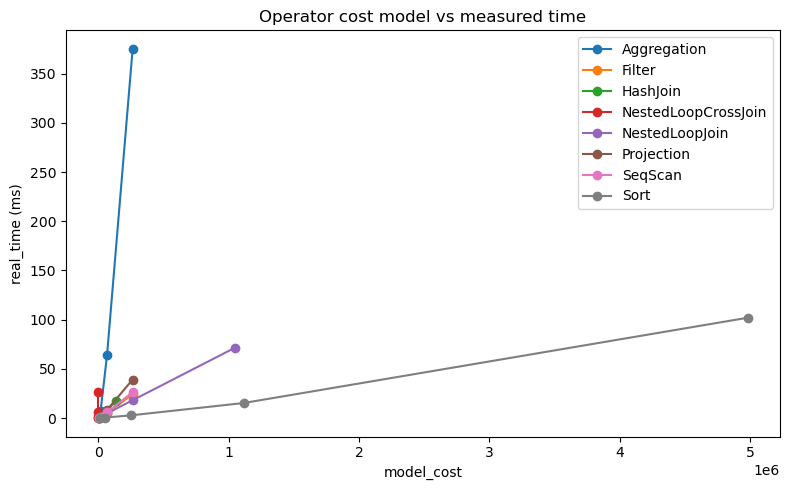

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
for op, grp in df.groupby('operator'):
    ax.plot(grp['model_cost'], grp['real_time_ms'], marker='o', label=op)

ax.set_xlabel('model_cost')
ax.set_ylabel('real_time (ms)')
ax.set_title('Operator cost model vs measured time')
ax.legend()
plt.tight_layout()
plt.show()